In [166]:
from utils import *
import matplotlib.pyplot as plt
import numpy as np
import torch
from pprint import pprint

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


{'telescope_diameter': 8.0,
 'oversizing_factor': 1.0666666666666667,
 'wavelength_sci': 2.2e-06,
 'num_modes': 25,
 'zero_magnitude_flux': 389999999.99999994,
 'stellar_magnitude': 5.0,
 'env_delta_t': 0.001,
 'pixels': 64,
 'num_iterations': 10,
 'coronagraph_charge': 6,
 'num_airy': 7,
 'pixels_per_spacial_res': 2,
 'num_noise_modes': 10,
 'diversity_enabled': True,
 'nudge_magnitude': 3e-07,
 'nudge_mode_indices': [3],
 'num_diversity_pairs': 1,
 'obs_noise_enabled': False,
 'obs_noise_level': 0.1,
 'obs_delta_t': 0.001,
 'include_slopes': True,
 'action_scale': 1e-08,
 'dm_clip': None,
 'lyot_fraction': 0.8,
 'basis': 'orthogonal',
 'mode_range': {'__type': 'slice', 'start': 0, 'stop': 25, 'step': None}}

In [208]:
def analyze_model_path(path, repetitions=50, num_convergence_iterations=10):
    experiment_output = {}
    model, env, metrics_data = load_model(path)  # path to the model checkpoint
    print(f"env.get_contrast(): {env.get_contrast(delta_t=1e15)}")

    if metrics_data['args'].get('fc1_encoder_enabled', False): model_type = "cnn"
    elif metrics_data['args'].get('fc1_activation', 'leaky_relu') == 'leaky_relu': model_type = "mlp"
    else: model_type = "linear model"

    print(f"Analyzing model of type: {model_type}")
    batch_size = metrics_data['args'].get('batch_size', 2048)
    hidden_size = metrics_data['args'].get('fc1_hidden', 25)
    split_vector = metrics_data['args'].get('split_vector', False)
    filter_channels = metrics_data['args'].get('fc1_filter_channels', [8, 16, 32])
    filter_sizes = metrics_data['args'].get('fc1_filter_sizes', [3, 3, 3])
    mag_cost = metrics_data['args'].get('mag_cost', 1.0)
    datapath = metrics_data['args'].get('datapath', None)
    total_params = sum(p.numel() for p in model.parameters())
    info = {}
    info["total params"] = total_params
    info["datapath"] = datapath
    info["batch size"] = batch_size
    info["hidden size"] = hidden_size
    info["split vector"] = split_vector
    info["filter channels"] = filter_channels
    info["filter sizes"] = filter_sizes
    info["mag cost"] = mag_cost

    experiment_output["model info"] = info
    experiment_output["env config"] = metrics_data['dataset_meta']['environment_config']
    experiment_output["model type"] = model_type
    
    train_history, val_history = get_model_history(metrics_data)
    experiment_output["min val loss"] = np.min(val_history)
    experiment_output["final val loss"] = val_history[-1]
    experiment_output[" train loss"] = np.min(train_history)
    experiment_output["final train loss"] = train_history[-1]

    noise_levels = np.logspace(-8, -6, num=7)
    noise_levels = np.concatenate((noise_levels, [2e-6]))
    # print(f"Testing noise levels: {noise_levels}")

    print(f"=====BEGINNING OOD TESTING=====")

    evaluation_stats1, predictions1, truths1 = test_noise_levels(model, env, metrics_data, noise_levels=noise_levels, noise_mode_amounts=[25], repetitions=repetitions, loops=1, delta_t=1e-1)
    experiment_output["exp1 evaluation stats"] = evaluation_stats1

    # optimal_scalings = compute_optimal_scalings(predictions1, truths1, noise_levels)
    # print(f"Optimal scalings: {optimal_scalings}")

    evaluation_stats2, predictions2, truths2 = test_noise_levels(model, env, metrics_data, noise_levels=[metrics_data['dataset_meta']['dataset_config']['dm_random_noise']], noise_mode_amounts=[10, 25, 35, 50, 100, 500], repetitions=repetitions, loops=1, delta_t=1e-1)
    experiment_output["exp2 evaluation stats"] = evaluation_stats2

    evaluation_stats3, predictions3, truths3 = test_noise_levels(model, env, metrics_data, noise_levels=noise_levels, noise_mode_amounts=[25], repetitions=repetitions // 7 + 1, loops=7, delta_t=1e-1)
    experiment_output["exp3 evaluation stats"] = evaluation_stats3

    evaluation_stats4, predictions4, truths4 = test_noise_levels(model, env, metrics_data, noise_levels=[metrics_data['dataset_meta']['dataset_config']['dm_random_noise']], noise_mode_amounts=[10, 25, 35, 50, 100, 500], repetitions=repetitions // 7 + 1, loops=7, delta_t=1e-1)
    experiment_output["exp4 evaluation stats"] = evaluation_stats4

    evaluation_stats5, predictions5, truths5 = test_noise_levels(model, env, metrics_data, noise_levels=noise_levels, noise_mode_amounts=[25], repetitions=repetitions // 3 + 1, loops=3, delta_t=1e-1)
    experiment_output["exp5 evaluation stats"] = evaluation_stats5

    print(f"=====BEGINNING CONVERGENCE TESTING=====")

    _, convergence, truths = test_noise_levels(model, env, metrics_data, noise_levels=[metrics_data['dataset_meta']['dataset_config']['dm_random_noise']], noise_mode_amounts=[25], repetitions=3, loops=20, delta_t=1e-1)
    convergence = convergence.reshape((convergence.shape[-2], convergence.shape[-1]))
    truths = truths.reshape((truths.shape[-2], truths.shape[-1]))
    convergence_mean = np.mean(convergence, axis=0)
    convergence_stds = np.std(convergence, axis=0)

    experiment_output["convergence"] = convergence_mean
    experiment_output["convergence std"] = np.mean(convergence_stds)

    convergence_stats, convergence, truths = test_noise_levels(model, env, metrics_data, noise_levels=[metrics_data['dataset_meta']['dataset_config']['dm_random_noise']], noise_mode_amounts=[25], repetitions=3, loops=20, delta_t=1e-1, bias=convergence_mean)

    convergence = convergence.reshape((convergence.shape[-2], convergence.shape[-1]))
    truths = truths.reshape((truths.shape[-2], truths.shape[-1]))
    # convergence_mean = np.mean(convergence, axis=0)
    # convergence_stds = np.std(convergence, axis=0)

    experiment_output["convergence_stats"] = convergence_stats
    # experiment_output["convergence with bias"] = convergence_mean
    # experiment_output["convergence with bias std"] = np.mean(convergence_stds)

    cur_convergence = convergence_mean.copy()
    for _ in range(num_convergence_iterations):
        convergence_stats, convergence, truths = test_noise_levels(model, env, metrics_data, noise_levels=[metrics_data['dataset_meta']['dataset_config']['dm_random_noise']], noise_mode_amounts=[25], repetitions=3, loops=20, delta_t=1e-1, bias=cur_convergence)

        convergence = convergence.reshape((convergence.shape[-2], convergence.shape[-1]))
        truths = truths.reshape((truths.shape[-2], truths.shape[-1]))
        cur_convergence += np.mean(convergence, axis=0)
    
    experiment_output["convergence after iterations"] = cur_convergence
    experiment_output["convergence after iterations std"] = np.mean(convergence_stds)
    experiment_output["convergence stats after iterations"] = convergence_stats
    experiment_output["num convergence iterations"] = num_convergence_iterations

    print(f"=====OPTIMAL SCALING TESTING=====")
    optimal_scalings = compute_optimal_scalings(predictions1, truths1, noise_levels)
    # print(f"Optimal scalings: {optimal_scalings}")
    experiment_output["optimal scalings"] = optimal_scalings

    scaling_stats, _, __ = test_noise_levels(model, env, metrics_data, noise_levels=noise_levels, noise_mode_amounts=[25], repetitions=repetitions, loops=1, delta_t=1e-1, alpha_lookup=optimal_scalings)
    experiment_output["exp scaling stats"] = scaling_stats
    
    return experiment_output


In [253]:
def get_convergence_images(path, repetitions=50, num_convergence_iterations=10):
    model, env, metrics_data = load_model(path)  # path to the model checkpoint

    print(f"=====BEGINNING CONVERGENCE TESTING=====")

    # evaluation_stats3, predictions3, truths3 = test_noise_levels(model, env, metrics_data, noise_levels=[1e-7], noise_mode_amounts=[25], repetitions=1, loops=20, delta_t=1e-1)
    
    # img = env.get_camera_image(delta_t=1e-3)
    # plt.imshow(img, cmap='inferno')
    # plt.axis('off')
    # plt.show()

    _, predictions, truths = test_noise_levels(model, env, metrics_data, noise_levels=[metrics_data['dataset_meta']['dataset_config']['dm_random_noise']], noise_mode_amounts=[25], repetitions=25000, loops=1, delta_t=1e-1)

    residuals = truths - predictions

    print(f"Residuals shape: {residuals.shape}")
    residuals = residuals.reshape((residuals.shape[-2], residuals.shape[-1]))

    print(f"Residuals reshaped: {residuals.shape}")
    surface = env.deformable_mirror.surface
    residual_surface = np.zeros_like(surface)

    for i in range(residuals.shape[0]):
        env.deformable_mirror.flatten()
        env.deformable_mirror.actuators = residuals[i]

        residual_surface += env.deformable_mirror.surface / residuals.shape[0]
    
    residual_surface = np.reshape(residual_surface, (68,68))

    plt.imshow(residual_surface, cmap='RdBu', vmin=-3e-8, vmax=3e-8)
    plt.colorbar(label='Surface Deformation (nm)')
    plt.title('Average Residual DM Surface Deformation')
    plt.axis('off')
    plt.show()

    return residual_surface




In [249]:
import os 

folders_to_analyze = [r'cnn\orth rand']# [r'cnn\LA new', r'cnn\orth new']# [r'mlp\LA', r'mlp\orth', r'linear\LA', r'linear\orth', r'mlp\orth rand', r'mlp\LA rand']

prefix_path = r"A:\Projects\DM + RL\RL\models\final"

missing_folders = [
    folder for folder in folders_to_analyze
    if not os.path.isdir(os.path.join(prefix_path, folder))
]
if missing_folders:
    raise FileNotFoundError(f"Missing folders under '{prefix_path}': {missing_folders}")

all_analysis_results = {}
for folder in folders_to_analyze:
    folder_path = os.path.join(prefix_path, folder)
    all_analysis_results[folder] = {}
    for experiment in os.listdir(folder_path):
        experiment_path = os.path.join(folder_path, experiment)
        if os.path.isdir(experiment_path):
            print(f"Analyzing experiment at: {experiment_path}")
            analysis_results = analyze_model_path(experiment_path, repetitions=50, num_convergence_iterations=10)
            all_analysis_results[folder][experiment] = analysis_results



Analyzing experiment at: A:\Projects\DM + RL\RL\models\final\cnn\orth rand\exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images
initializing coronagraph env. might take a minute.


KeyboardInterrupt: 

In [207]:
import json

pprint("Final analysis results:")

def _json_default(obj):
    if isinstance(obj, (np.integer, np.floating, np.bool_)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, set):
        return list(obj)
    raise TypeError(f"Object of type {type(obj).__name__} is not JSON serializable")

output_path = os.path.join(prefix_path, "cnn_analysis_results_orth_rand.json")
with open(output_path, "w") as f:
    json.dump(all_analysis_results, f, default=_json_default, indent=2)
print(f"Saved JSON to {output_path}")

'Final analysis results:'
Saved JSON to A:\Projects\DM + RL\RL\models\final\cnn_analysis_results_orth_rand.json


In [ ]:
surfaces = {}

for experiment_name, experiment_path in paths.items():
    if os.path.isdir(experiment_path):
        print(f"Analyzing experiment at: {experiment_path}")
        analysis_results = get_convergence_images(experiment_path, repetitions=50, num_convergence_iterations=10)
        surfaces[experiment_name] = analysis_results

Analyzing experiment at: A:\Projects\DM + RL\RL\models\final\cnn\orth new\exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images
initializing coronagraph env. might take a minute.
=====BEGINNING CONVERGENCE TESTING=====


noise sweep:   0%|          | 0/1 [00:00<?, ?it/s]

In [236]:
paths = {
    "cnn": r"A:\Projects\DM + RL\RL\models\final\cnn\orth new\exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images",
    "cnn_small": r"A:\Projects\DM + RL\RL\models\final\cnn\orth new\exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images small",
    "mlp_small": r"A:\Projects\DM + RL\RL\models\final\mlp\orth\exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images",
    "mlp_large": r"A:\Projects\DM + RL\RL\models\final\mlp\orth\exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images",
    "linear": r"A:\Projects\DM + RL\RL\models\final\linear\orth\exp-fc1-zscore-ep5000-bs2048-lr1e-3-s42-h25-images",
}

Analyzing experiment at: A:\Projects\DM + RL\RL\models\final\cnn\orth new\exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images
initializing coronagraph env. might take a minute.
=====BEGINNING CONVERGENCE TESTING=====


noise sweep: 100%|██████████| 1/1 [06:31<00:00, 391.10s/it]


Residuals shape: (1, 1, 5000, 25)
Residuals reshaped: (5000, 25)


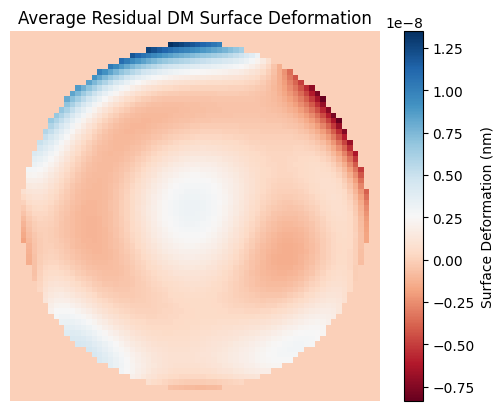

Analyzing experiment at: A:\Projects\DM + RL\RL\models\final\cnn\orth new\exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images small
initializing coronagraph env. might take a minute.
=====BEGINNING CONVERGENCE TESTING=====


noise sweep: 100%|██████████| 1/1 [06:25<00:00, 385.86s/it]


Residuals shape: (1, 1, 5000, 25)
Residuals reshaped: (5000, 25)


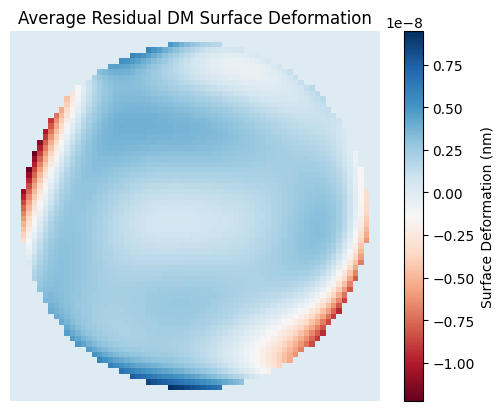

Analyzing experiment at: A:\Projects\DM + RL\RL\models\final\mlp\orth\exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images
initializing coronagraph env. might take a minute.
=====BEGINNING CONVERGENCE TESTING=====


noise sweep: 100%|██████████| 1/1 [06:06<00:00, 366.73s/it]


Residuals shape: (1, 1, 5000, 25)
Residuals reshaped: (5000, 25)


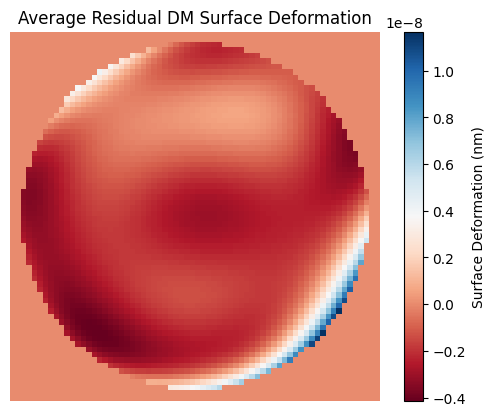

Analyzing experiment at: A:\Projects\DM + RL\RL\models\final\mlp\orth\exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images
initializing coronagraph env. might take a minute.
=====BEGINNING CONVERGENCE TESTING=====


noise sweep: 100%|██████████| 1/1 [06:35<00:00, 395.54s/it]


Residuals shape: (1, 1, 5000, 25)
Residuals reshaped: (5000, 25)


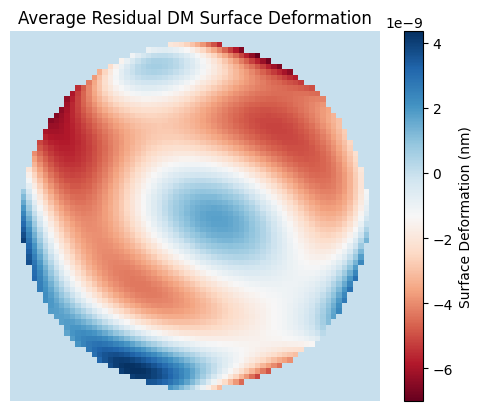

Analyzing experiment at: A:\Projects\DM + RL\RL\models\final\linear\orth\exp-fc1-zscore-ep5000-bs2048-lr1e-3-s42-h25-images
initializing coronagraph env. might take a minute.
=====BEGINNING CONVERGENCE TESTING=====


noise sweep: 100%|██████████| 1/1 [06:25<00:00, 385.86s/it]


Residuals shape: (1, 1, 5000, 25)
Residuals reshaped: (5000, 25)


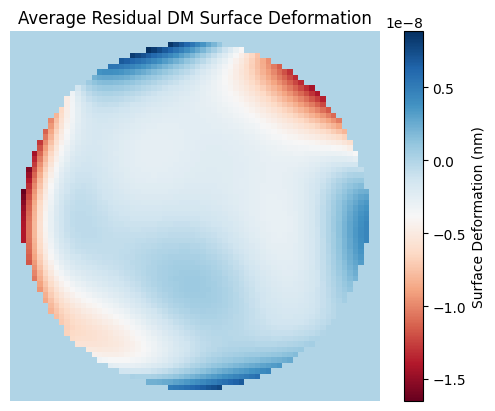

In [246]:


for experiment_name, experiment_path in paths.items():
    if os.path.isdir(experiment_path):
        print(f"Analyzing experiment at: {experiment_path}")
        analysis_results = get_convergence_images(experiment_path, repetitions=50, num_convergence_iterations=10)


Analyzing experiment at: A:\Projects\DM + RL\RL\models\final\cnn\orth new\exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images
initializing coronagraph env. might take a minute.
=====BEGINNING CONVERGENCE TESTING=====


noise sweep: 100%|██████████| 1/1 [06:03<00:00, 363.55s/it]


Residuals shape: (1, 1, 5000, 25)
Residuals reshaped: (5000, 25)


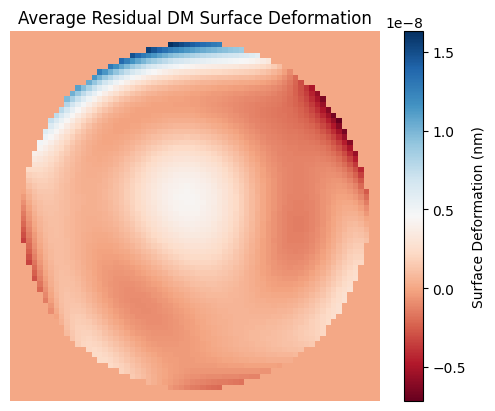

Analyzing experiment at: A:\Projects\DM + RL\RL\models\final\cnn\orth new\exp-fc1-zscore-ep500-bs256-lr1e-3-s42-h64-images small
initializing coronagraph env. might take a minute.
=====BEGINNING CONVERGENCE TESTING=====


noise sweep: 100%|██████████| 1/1 [06:00<00:00, 360.81s/it]


Residuals shape: (1, 1, 5000, 25)
Residuals reshaped: (5000, 25)


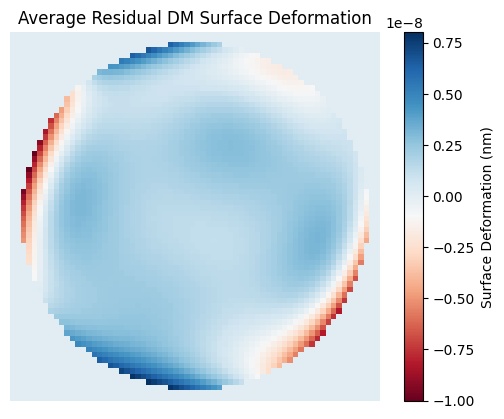

Analyzing experiment at: A:\Projects\DM + RL\RL\models\final\mlp\orth\exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h128-64-images
initializing coronagraph env. might take a minute.
=====BEGINNING CONVERGENCE TESTING=====


noise sweep: 100%|██████████| 1/1 [06:03<00:00, 363.33s/it]


Residuals shape: (1, 1, 5000, 25)
Residuals reshaped: (5000, 25)


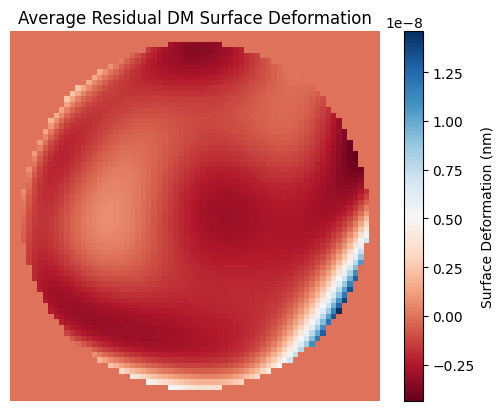

Analyzing experiment at: A:\Projects\DM + RL\RL\models\final\mlp\orth\exp-fc1-zscore-ep1500-bs256-lr1e-3-s42-h512-256-128-images
initializing coronagraph env. might take a minute.
=====BEGINNING CONVERGENCE TESTING=====


noise sweep: 100%|██████████| 1/1 [06:08<00:00, 368.89s/it]


Residuals shape: (1, 1, 5000, 25)
Residuals reshaped: (5000, 25)


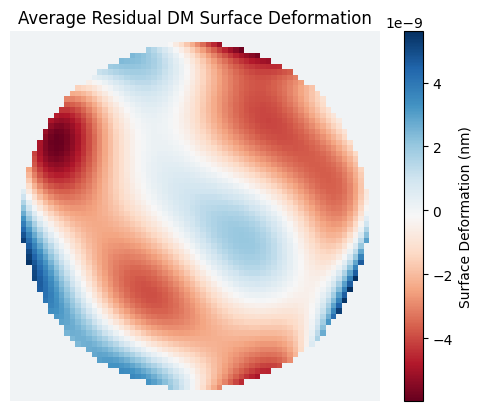

Analyzing experiment at: A:\Projects\DM + RL\RL\models\final\linear\orth\exp-fc1-zscore-ep5000-bs2048-lr1e-3-s42-h25-images
initializing coronagraph env. might take a minute.
=====BEGINNING CONVERGENCE TESTING=====


noise sweep: 100%|██████████| 1/1 [06:01<00:00, 361.96s/it]


Residuals shape: (1, 1, 5000, 25)
Residuals reshaped: (5000, 25)


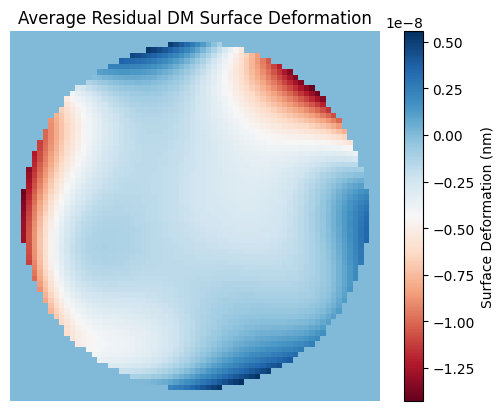

In [247]:
for experiment_name, experiment_path in paths.items():
    if os.path.isdir(experiment_path):
        print(f"Analyzing experiment at: {experiment_path}")
        analysis_results = get_convergence_images(experiment_path, repetitions=50, num_convergence_iterations=10)
